Clustering Algorithms

Davies-Bouldien Index and Silhouette score

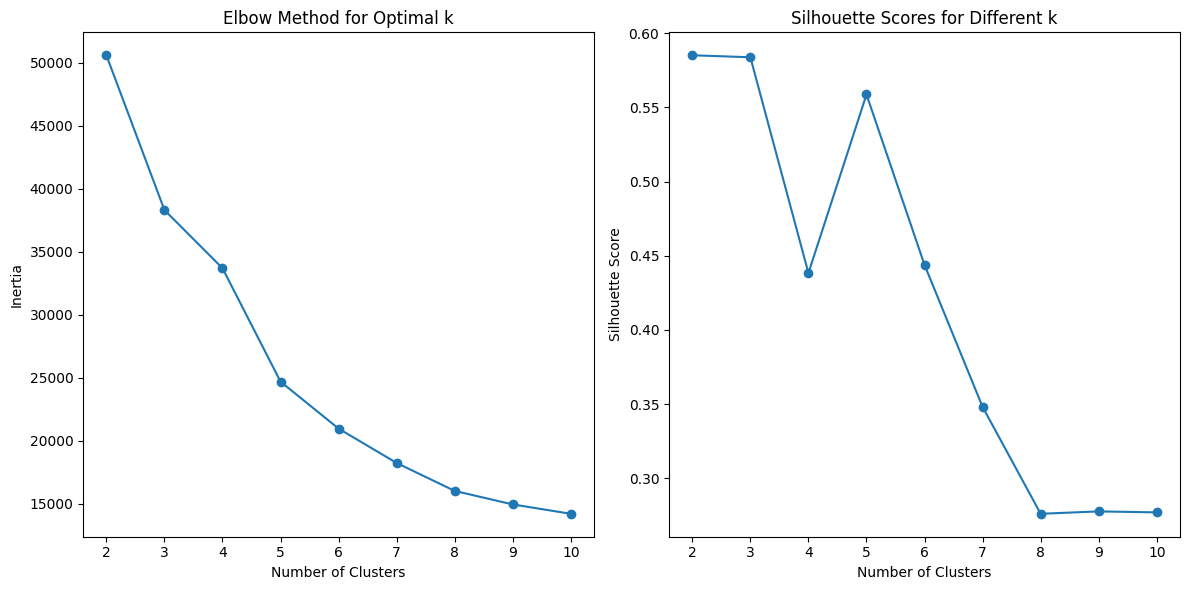

Silhouette Score: 0.4383
Davies-Bouldin Index: 1.0727


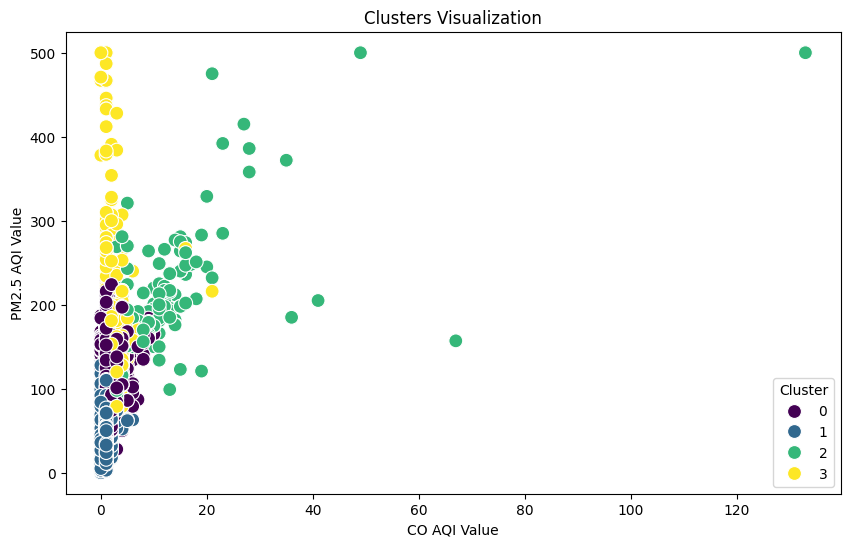

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('Data\Real-Data\AQI and Lat Long of Countries.csv')

# Select features for clustering (you can choose other relevant features)
feature_columns = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = data[feature_columns]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the elbow method
inertia = []
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the elbow method results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

# Plotting silhouette scores
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Choose the optimal number of clusters (let's say we choose 4 based on the elbow method)
optimal_clusters = 4

# Fit KMeans with optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(X_scaled)

# Get cluster labels and add to original data
data['Cluster'] = kmeans.labels_

# Evaluate clustering quality
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
davies_bouldin = davies_bouldin_score(X_scaled, kmeans.labels_)

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['CO AQI Value'], y=data['PM2.5 AQI Value'], hue=data['Cluster'], palette='viridis', s=100)
plt.title('Clusters Visualization')
plt.xlabel('CO AQI Value')
plt.ylabel('PM2.5 AQI Value')
plt.legend(title='Cluster')
plt.show()

K-Means Clustering  

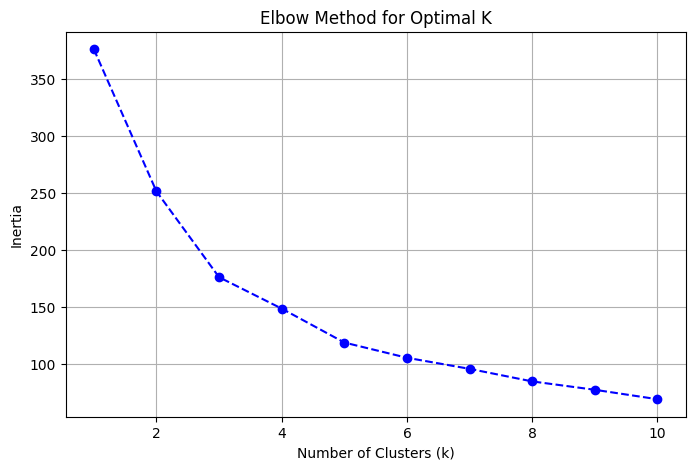

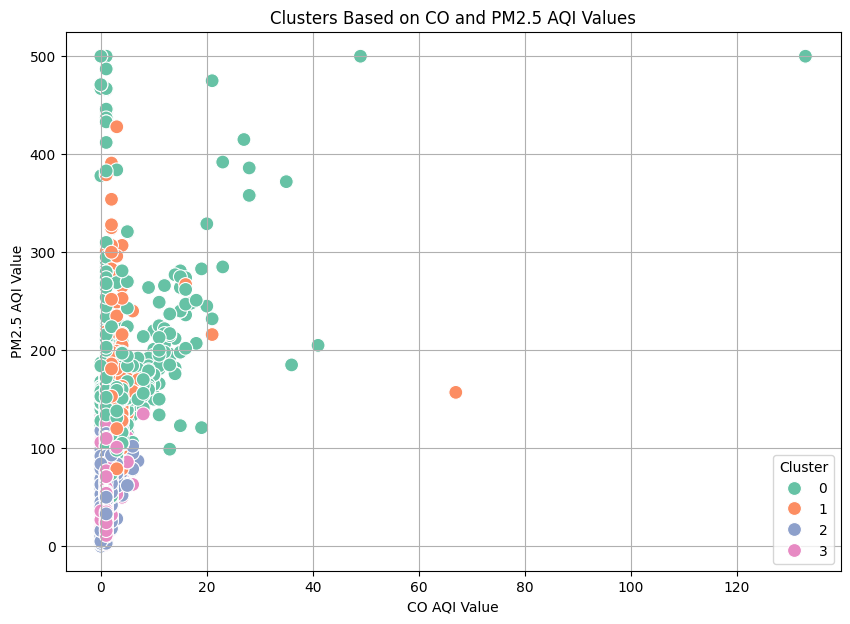

Cluster Centroids (Original Scale):
   CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value
0      3.260784        19.450980      13.571078       128.163725
1      3.314088       139.274827       2.836028       153.390300
2      1.003467        21.326827       3.305124        46.998459
3      1.011033        41.071950       1.417094        47.376535


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Data Cleaning and Preparation
data = data.dropna(subset=['Country'])  # Remove rows with missing 'Country'

# Select relevant features for clustering
features = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = data[features]

# Normalize the features for clustering
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)  # Check for 1 to 10 clusters

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Choose optimal number of clusters (e.g., from the elbow point)
optimal_k = 4  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data['CO AQI Value'], 
    y=data['PM2.5 AQI Value'], 
    hue=data['Cluster'], 
    palette='Set2', 
    s=100
)
plt.title('Clusters Based on CO and PM2.5 AQI Values')
plt.xlabel('CO AQI Value')
plt.ylabel('PM2.5 AQI Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Display cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
print("Cluster Centroids (Original Scale):")
print(centroids_df)

# Save the clustered data to a CSV file (optional)
data.to_csv('Data\Real-Data\AQI and Lat Long of Countries.csv', index=False)


DBSCAN (Density-Based Spatial Clustering of Applications with Noise)  Clustering

Estimated number of clusters: 1
Estimated number of noise points: 5


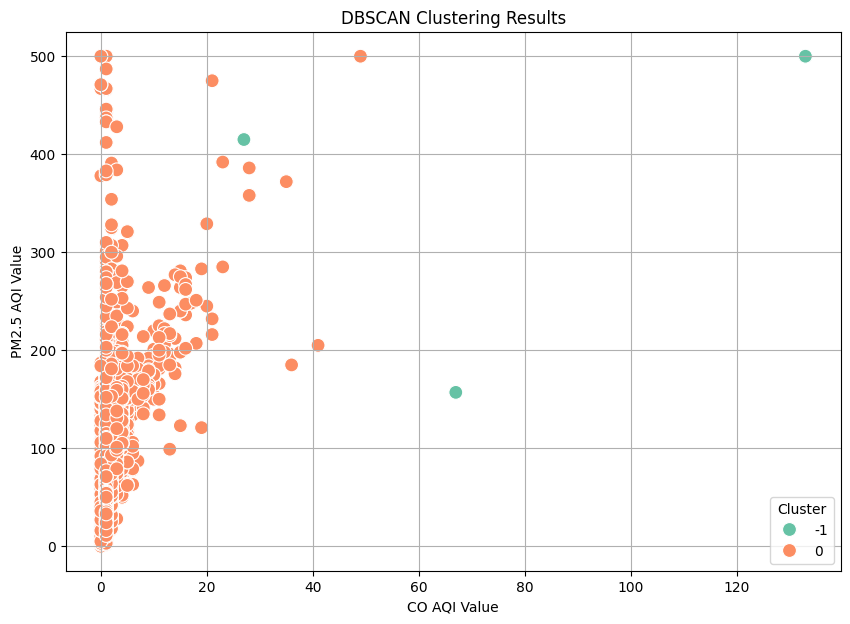

Noise Points:
                       Country     City  AQI Value    AQI Category  \
960          Republic of Korea    Seoul        421       Hazardous   
3768  United States of America  Durango        500       Hazardous   
3769  United States of America  Durango        500       Hazardous   
3770  United States of America  Durango        500       Hazardous   
9286                  Malaysia     Miri        209  Very Unhealthy   

      CO AQI Value                 CO AQI Category  Ozone AQI Value  \
960             27                            Good                0   
3768           133  Unhealthy for Sensitive Groups                0   
3769           133  Unhealthy for Sensitive Groups                0   
3770           133  Unhealthy for Sensitive Groups                0   
9286            67                        Moderate              209   

     Ozone AQI Category  NO2 AQI Value NO2 AQI Category  PM2.5 AQI Value  \
960                Good             91         Moderate       

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Data Cleaning and Preparation
data = data.dropna(subset=['Country'])  # Remove rows with missing 'Country'

# Select relevant features for clustering
features = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
X = data[features]

# Normalize the features for clustering
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
# Adjust 'eps' (radius) and 'min_samples' for your dataset
dbscan = DBSCAN(eps=0.3, min_samples=5)
data['Cluster'] = dbscan.fit_predict(X_scaled)

# Analyze the results
n_clusters = len(set(data['Cluster']) - {-1})  # Exclude noise (-1)
n_noise = sum(data['Cluster'] == -1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data['CO AQI Value'], 
    y=data['PM2.5 AQI Value'], 
    hue=data['Cluster'], 
    palette='Set2', 
    s=100,
    legend='full'
)
plt.title('DBSCAN Clustering Results')
plt.xlabel('CO AQI Value')
plt.ylabel('PM2.5 AQI Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Display noise points
noise_points = data[data['Cluster'] == -1]
print("Noise Points:")
print(noise_points)

# Save the clustered data to a CSV file (optional)
data.to_csv('D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv', index=False)
